In [1]:
!sudo apt-get install tesseract-ocr -y
!pip install pytesseract
!pip install opencv-python
!pip install matplotlib
!pip install pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-06-20 145445.png to Screenshot 2026-06-20 145445.png


In [3]:
import os

print(os.listdir())

['.config', 'Screenshot 2026-06-20 145445.png', 'sample_data']


In [4]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

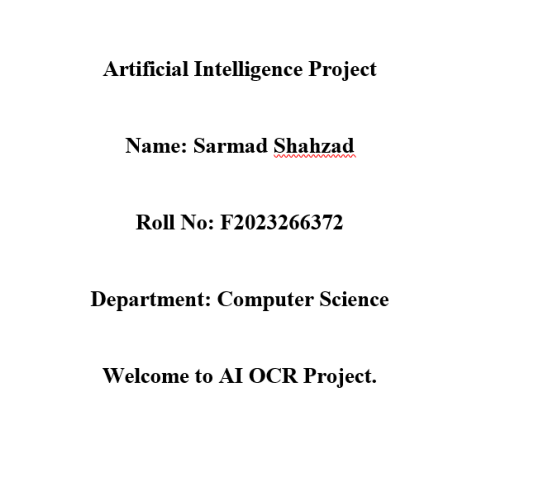

In [5]:
# Read the image
image = cv2.imread("Screenshot 2026-06-20 145445.png")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [6]:
# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Extract text using OCR
text = pytesseract.image_to_string(gray)

# Print extracted text
print("Extracted Text:\n")
print(text)

Extracted Text:

Artificial Intelligence Project
Name: Sarmad Shahzad.
Roll No: F2023266372

Department: Computer Science

Welcome to AI OCR Project.



Saving Screenshot 2026-06-06 134934.png to Screenshot 2026-06-06 134934.png

Processing Image: Screenshot 2026-06-06 134934.png


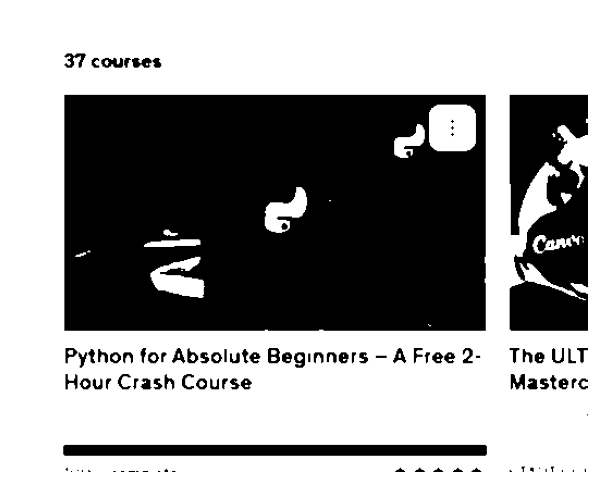

Extracted Text:
------------------------------
37 courses

  

Python for Absolute Beginners - AFree 2- The ULT
Hour Crash Course Masterc

 

------------------------------
Words: 15
Characters: 95
Lines: 9


In [8]:
from google.colab import files
import cv2
import pytesseract
import matplotlib.pyplot as plt

uploaded = files.upload()

for image_name in uploaded.keys():
    print("\n==============================")
    print("Processing Image:", image_name)
    print("==============================")

    image = cv2.imread(image_name)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, threshold = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    plt.figure(figsize=(8,6))
    plt.imshow(threshold, cmap="gray")
    plt.axis("off")
    plt.show()

    text = pytesseract.image_to_string(threshold)

    print("Extracted Text:")
    print("------------------------------")
    print(text)

    words = text.split()
    lines = text.splitlines()
    characters = len(text)

    print("------------------------------")
    print("Words:", len(words))
    print("Characters:", characters)
    print("Lines:", len(lines))

 AI IMAGE TEXT RECOGNITION SYSTEM


Saving car image.png to car image.png

Image Name: car image.png

Original Image:


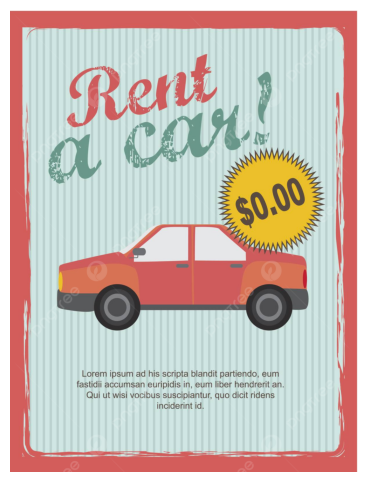


Processed Image:


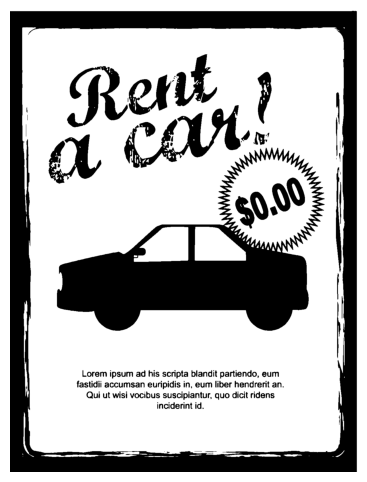


Extracted Text:
------------------------------------
Lorem ipsum ad his scripta blandit partiendo, eum
fastidii accumsan euripidis in, eum liber hendrerit an.
Qui ut wisi vocibus suscipiantur, quo dicit ridens
inciderint id.

 

------------------------------------
Statistics:
Words: 26
Characters: 176
Lines: 7
Confidence Score: 93.63 %
Time Taken: 1.97 seconds

✅ All OCR results saved successfully in: extracted_text_results.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from google.colab import files
import cv2
import pytesseract
import matplotlib.pyplot as plt
import time
import os

print("====================================")
print(" AI IMAGE TEXT RECOGNITION SYSTEM")
print("====================================")

uploaded = files.upload()

all_results = ""

for image_name in uploaded.keys():
    start_time = time.time()

    print("\n====================================")
    print("Image Name:", image_name)
    print("====================================")

    image = cv2.imread(image_name)

    if image is None:
        print("Error: Image not found or invalid format.")
        continue

    # Show original image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print("\nOriginal Image:")
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

    # Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, threshold = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    print("\nProcessed Image:")
    plt.figure(figsize=(8, 6))
    plt.imshow(threshold, cmap="gray")
    plt.axis("off")
    plt.show()

    # OCR text extraction
    text = pytesseract.image_to_string(threshold)

    # Confidence score
    data = pytesseract.image_to_data(
        threshold, output_type=pytesseract.Output.DICT
    )

    confidences = []
    for conf in data["conf"]:
        try:
            conf = int(conf)
            if conf > 0:
                confidences.append(conf)
        except:
            pass

    if len(confidences) > 0:
        avg_confidence = sum(confidences) / len(confidences)
    else:
        avg_confidence = 0

    # Statistics
    words = text.split()
    lines = text.splitlines()
    characters = len(text)
    end_time = time.time()
    time_taken = end_time - start_time

    print("\nExtracted Text:")
    print("------------------------------------")
    print(text)

    print("------------------------------------")
    print("Statistics:")
    print("Words:", len(words))
    print("Characters:", characters)
    print("Lines:", len(lines))
    print("Confidence Score:", round(avg_confidence, 2), "%")
    print("Time Taken:", round(time_taken, 2), "seconds")

    all_results += "\n====================================\n"
    all_results += "Image Name: " + image_name + "\n"
    all_results += "====================================\n"
    all_results += "Extracted Text:\n" + text + "\n"
    all_results += "Words: " + str(len(words)) + "\n"
    all_results += "Characters: " + str(characters) + "\n"
    all_results += "Lines: " + str(len(lines)) + "\n"
    all_results += "Confidence Score: " + str(round(avg_confidence, 2)) + "%\n"
    all_results += "Time Taken: " + str(round(time_taken, 2)) + " seconds\n"

# Save result in text file
file_name = "extracted_text_results.txt"

with open(file_name, "w", encoding="utf-8") as file:
    file.write(all_results)

print("\n✅ All OCR results saved successfully in:", file_name)

files.download(file_name)

# AI IMAGE TEXT RECOGNITION SYSTEM

### Project 4

**Developed By:** Your Name

**Technology Used:**
- Python
- Google Colab
- OpenCV
- Tesseract OCR
- Matplotlib

## Objective

The objective of this project is to recognize and extract text from images using Optical Character Recognition (OCR). The system preprocesses the image, extracts text, displays statistics, and saves the extracted text into a text file.

# Step 1: Install Required Libraries

# Step 2: Import Required Libraries

# Step 3: Upload Image

# Step 4: Image Preprocessing

# Step 5: Extract Text Using OCR

# Step 6: Save Results

# Step 7: Image Statistics

# Step 8: Save Results

# Conclusion

This project successfully extracts text from images using OCR. The system preprocesses images, recognizes text, calculates statistics, and saves the extracted results into a text file. It supports multiple image uploads and provides a simple AI-based text recognition solution.